<a href="https://colab.research.google.com/github/IsharaDeshan3/ML_2026_Y4S2/blob/main/IT22898548_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import os
from google.colab import files
import os

In [6]:
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [7]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.45GB/s]
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [9]:
import pandas as pd
df = pd.read_csv('creditcard.csv')

/tmp/ipykernel_250/3110688684.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


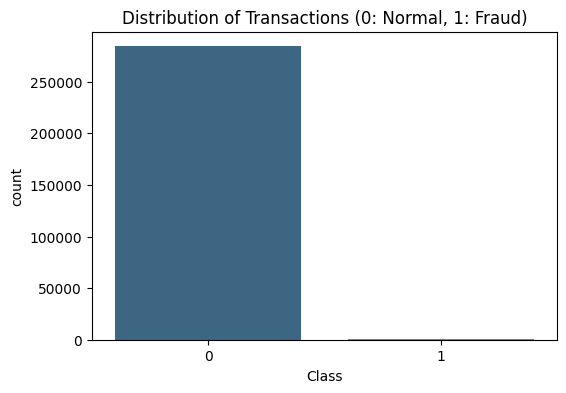

Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of Fraud vs. Legitimate transactions
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Transactions (0: Normal, 1: Fraud)')
plt.show()

# Print exact counts to mention in your report
print(df['Class'].value_counts())

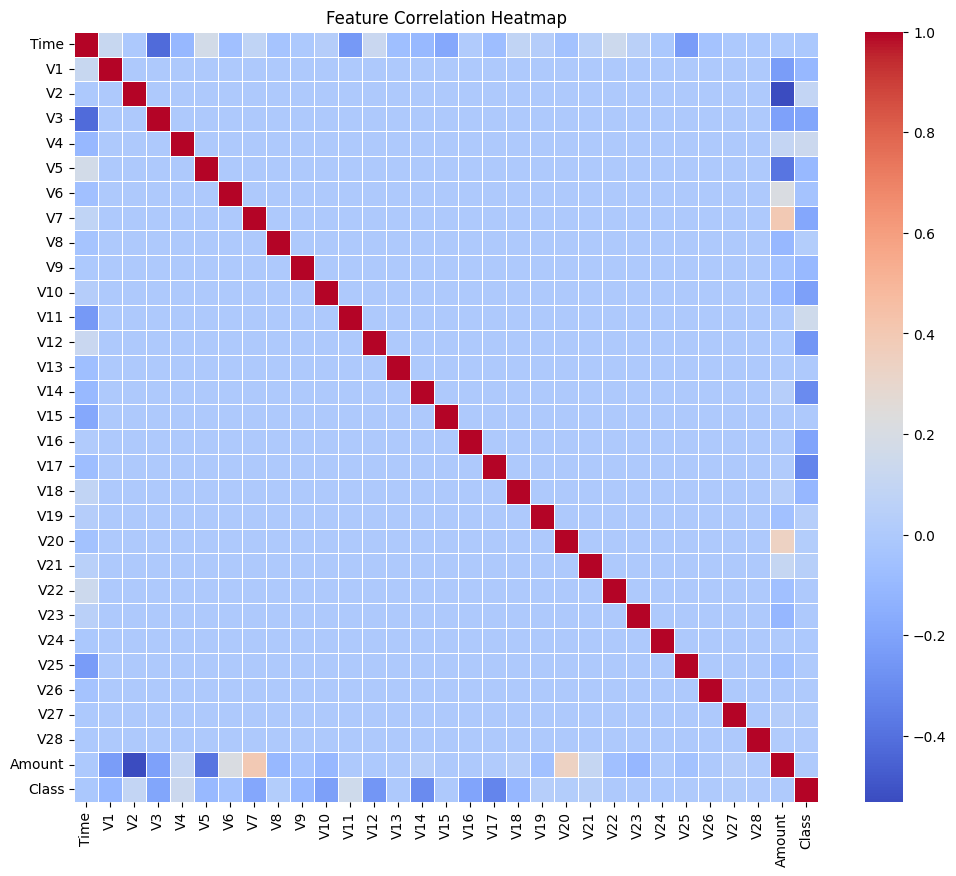

In [11]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

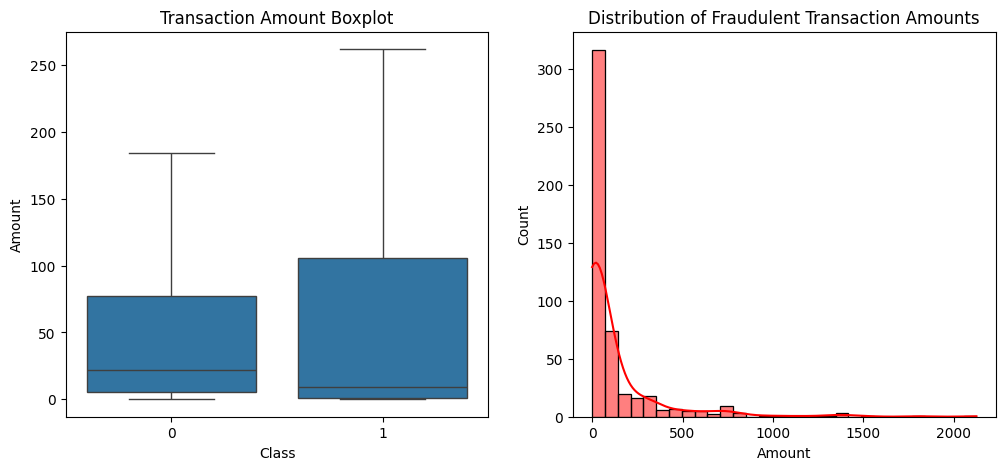

In [13]:
# Compare Amount distribution for Fraud and Normal
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
sns.boxplot(x="Class", y="Amount", data=df, ax=ax1, showfliers=False)
ax1.set_title('Transaction Amount Boxplot')

sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, kde=True, ax=ax2, color='red')
ax2.set_title('Distribution of Fraudulent Transaction Amounts')
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['normAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
X = df.drop(['Time', 'Amount', 'Class'], axis=1) # Choosing proper variables
y = df['Class']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
y_pred = knn.predict(X_test)